### Scenario:
"You’re part of a futuristic car-shopping app team! 🚀🚗"

Imagine you’re working for **AutoMatch**, a cutting-edge app that helps customers find their perfect car based on what matters most to them: price, safety, size, and maintenance cost. But here’s the catch — the app needs to quickly decide whether a car is unacceptable, acceptable, good, or very good without a human expert checking every single one.

Your mission?
Build a smart AI assistant that learns from past car data to predict the **acceptability** of any new car that comes into the system, so buyers get instant recommendations!

#### Why is this cool for you?
You get to act like a car expert using data, even if you don’t know much about cars.

You’ll learn how machines can help people make smarter choices in seconds.

It’s like building the “brain” behind the app that decides which cars are good deals.



#### Quiz Questions

1. **Which of these features do you think affects whether a car is "very good"? 🏆🚗🌟**
   a) Color of the car 🎨
   b) Safety rating 🛡️
   c) Number of cup holders ☕
   d) How loud the horn is 📢

2. **If a car has a very high maintenance cost, what do you think its acceptability rating would most likely be?**
   a) Very Good 🏆🚙🌈
   b) Good 🌟🚙👍
   c) Acceptable 🟢🚗🙂
   d) Unacceptable 🛑🚗💥

3. **True or False:**
   A car with a low buying price but poor safety could still be rated as "very good". ❓🚘

4. **Why do you think encoding categorical data (like ‘buying price’: low, medium, high) is important for a machine learning model?**
   a) Because machines only understand numbers 🤖🔢
   b) To make the data look prettier 🎨
   c) So the model can randomly guess 🎲
   d) To confuse the computer 🤯

5. **Imagine you’re the AI in the app — which feature would you weigh most heavily when deciding if a car is acceptable?**
   a) Color 🎨
   b) Safety 🛡️
   c) Number of doors 🚪
   d) Size of the luggage boot 🧳

6. **Bonus Challenge:**
   If you had to add one more feature to improve the car classification, what would it be and why? 🤔💡


1. Safety rating because it directly impacts the well-being of the passengers. A car with a high safety rating is more likely to be considered "very good" regardless of other features.
2. Acceptable or Unacceptable. High maintenance costs can deter buyers, making the car less appealing even if it has other good features.
3. False. A car with poor safety is unlikely to be rated as "very good"
4. a) Because machines only understand numbers. Encoding categorical data allows the model to process and learn from the features effectively.
5. b) Safety. Safety is a critical factor for most buyers, and a car with a high safety rating is more likely to be considered acceptable or better.
6. A feature like "car history" could be added to improve classification. Knowing if a car has been in accidents or has a history of big mechanical issues can significantly impact its acceptability rating.

### Let's begin by loading the dataset

In [1]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score

# Load dataset
df = pd.read_csv('dataset/cars_classification_dataset.csv')
df.head(10)

,buying,maint,doors,persons,lug_boot,safety,car
0,vhigh,vhigh,two,two,small,low,unacc
1,vhigh,vhigh,two,two,small,med,unacc
2,vhigh,vhigh,two,two,small,high,unacc
3,vhigh,vhigh,two,two,med,low,unacc
4,vhigh,vhigh,two,two,med,med,unacc
5,vhigh,vhigh,two,two,med,high,unacc
6,vhigh,vhigh,two,two,big,low,unacc
7,vhigh,vhigh,two,two,big,med,unacc
8,vhigh,vhigh,two,two,big,high,unacc
9,vhigh,high,two,two,small,low,unacc


#### Columns meanings:

##### What you have to do with this dataset:
Understand the Dataset:

The dataset contains information about different cars.

It usually includes features such as:

- Buying price

- Maintenance cost

- Number of doors

- Capacity in terms of persons

- Size of luggage boot

- Safety rating

The target variable is typically the car acceptability class (e.g., unacceptable, acceptable, good, very good).

# 1. Explore the Dataset

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   buying    1728 non-null   str  
 1   maint     1728 non-null   str  
 2   doors     1728 non-null   str  
 3   persons   1728 non-null   str  
 4   lug_boot  1728 non-null   str  
 5   safety    1728 non-null   str  
 6   car       1728 non-null   str  
dtypes: str(7)
memory usage: 140.1 KB


In [3]:
df.describe()


,buying,maint,doors,persons,lug_boot,safety,car
count,1728,1728,1728,1728,1728,1728,1728
unique,4,4,4,3,3,3,4
top,vhigh,vhigh,two,two,small,low,unacc
freq,432,432,432,576,576,576,1210


- From this tables we can see that the dataset has 7 columns and 1728 rows.
- All the data types are strings which mean that all the features are categorical.
- From the '.describe()' we can see that the data in the dataset is unbalanced.
- As we can see , the unacc class has the highest number of rows.
- The unacc class has 1210 rows, which is ~70% of the dataset.
- If we want to build a model that can predict the acceptability of a car, we need to make sure that the model is not biased towards the unacc class.

In [4]:
df.isnull().sum()

buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
car         0
dtype: int64

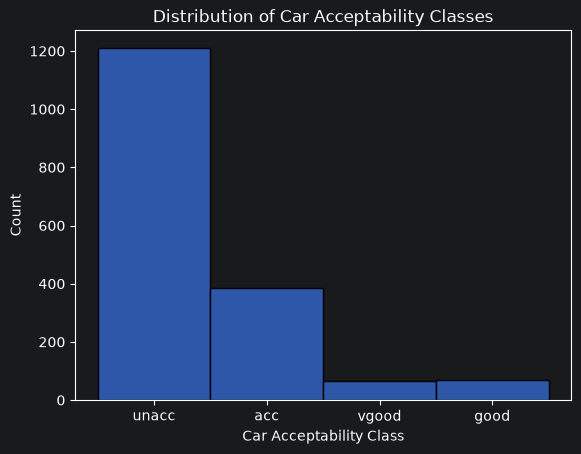

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['car'], bins="auto")
plt.title('Distribution of Car Acceptability Classes')
plt.xlabel('Car Acceptability Class')
plt.ylabel('Count')
plt.show()

- This histogram shows the distribution of car acceptability classes in the dataset.
- In the diagram we can see better the unbalanced data in the dataset.
- The unacc class has the highest number of rows (>1200), while the vgood class has the lowest number of rows (<200) .

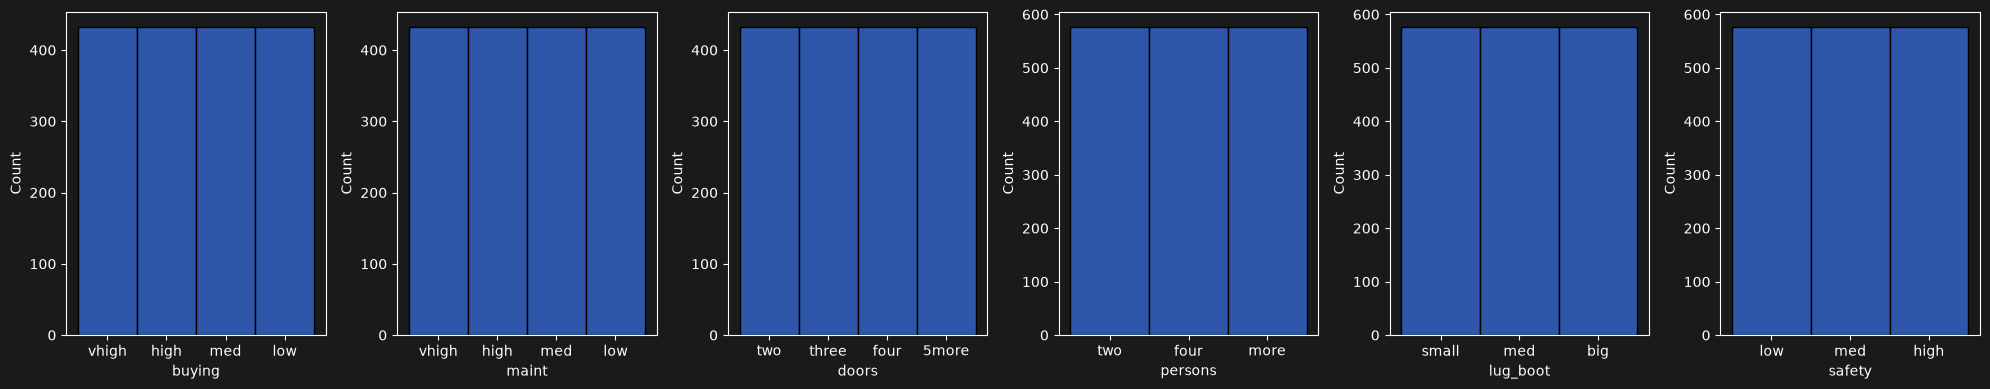

In [6]:
plt.figure(figsize=(20, 4))

columns_plot=df.columns.drop('car')

for i, column in enumerate(columns_plot):
    plt.subplot(1, len(columns_plot), i+1)
    sns.histplot(data=df, x=column, bins="auto")

plt.tight_layout()
plt.show()


- This histograms shows the distribution of the features in the dataset.
- We can see that the rest of the features expect for the 'car' feature are pretty balanced.

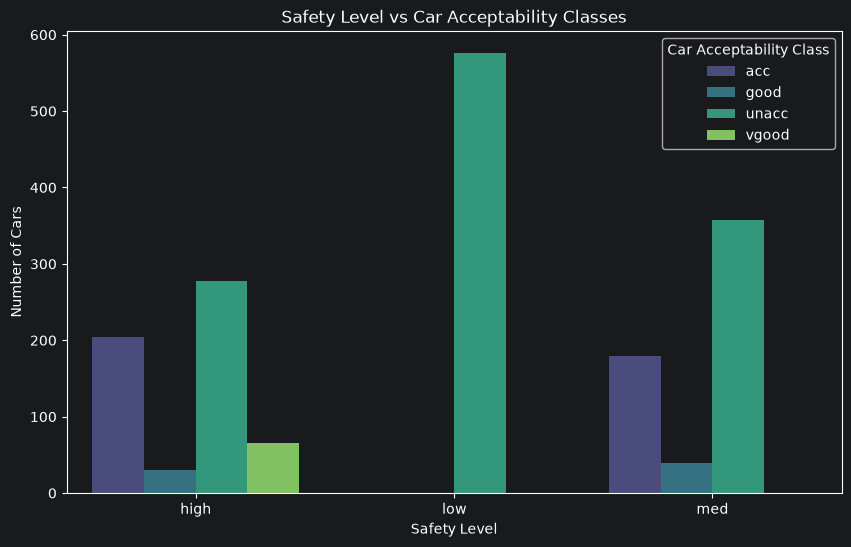

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt


grouped_data = df.groupby(['safety', 'car']).size().reset_index(name='appearances')

plt.figure(figsize=(10, 6))
sns.barplot(data=grouped_data,x='safety',y='appearances',hue='car',palette='viridis')

plt.title('Safety Level vs Car Acceptability Classes')
plt.xlabel('Safety Level')
plt.ylabel('Number of Cars')
plt.legend(title='Car Acceptability Class')

plt.show()

- The bar plot shows the relationship between safety levels and car acceptability classes.
- We can see that cars with low safety are classified as unacc meaning that the safety level is a very important feature in determining the acceptability of a car.
- We can also see that some cars with high and med safety are still classified as unacc, which means that there are other features that affect the acceptability of a car.

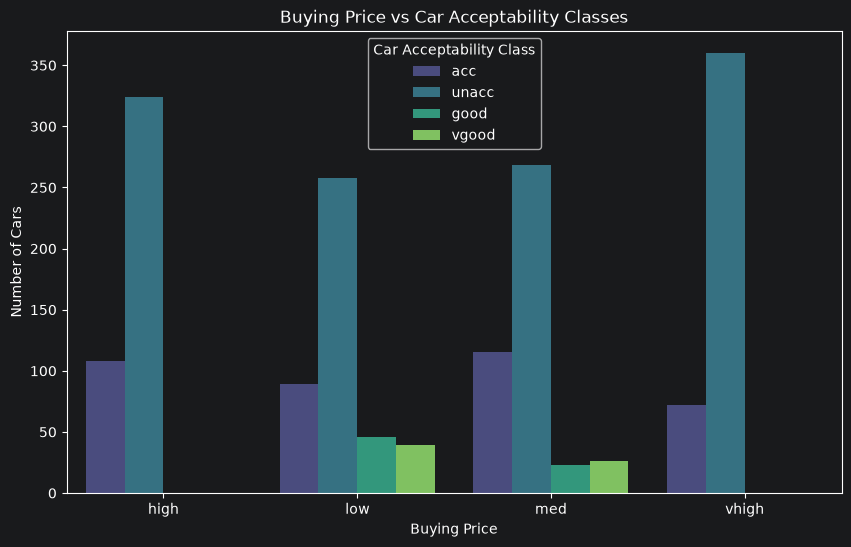

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt


grouped_data = df.groupby(['buying', 'car']).size().reset_index(name='appearances')

plt.figure(figsize=(10, 6))
sns.barplot(data=grouped_data,x='buying',y='appearances',hue='car',palette='viridis')

plt.title('Buying Price vs Car Acceptability Classes')
plt.xlabel('Buying Price')
plt.ylabel('Number of Cars')
plt.legend(title='Car Acceptability Class')

plt.show()

- The bar plot shows the relationship between buying price and car acceptability classes.
- We can see that the cars with high and vhigh buying prices tend to be classified as unacc or acc, while the cars with low and med buying prices tend to be classified as acc, good and vgood, which means that the buying price is also an important feature in determining the acceptability of a car.

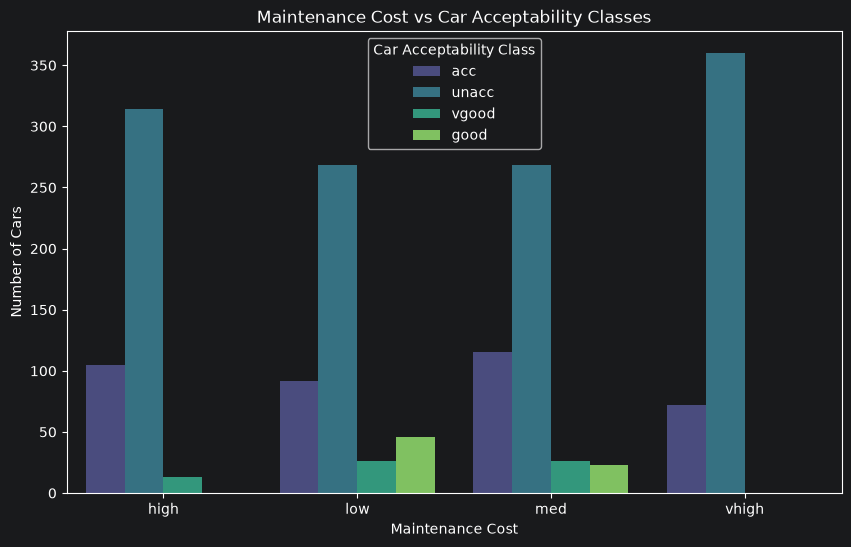

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt


grouped_data = df.groupby(['maint', 'car']).size().reset_index(name='appearances')

plt.figure(figsize=(10, 6))
sns.barplot(data=grouped_data,x='maint',y='appearances',hue='car',palette='viridis')

plt.title('Maintenance Cost vs Car Acceptability Classes')
plt.xlabel('Maintenance Cost')
plt.ylabel('Number of Cars')
plt.legend(title='Car Acceptability Class')

plt.show()

- The bar plot shows the relationship between maintenance cost and car acceptability classes.
- Even though the unacc class has the highest number of rows in all maintenance cost levels, we can see that the car maintenance cost is also an important feature in determining the acceptability of a car, as the cars with low maintenance costs tend to be classified as acc, good and vgood, while the cars with vhigh maintenance costs tend to be classified as unacc or acc.

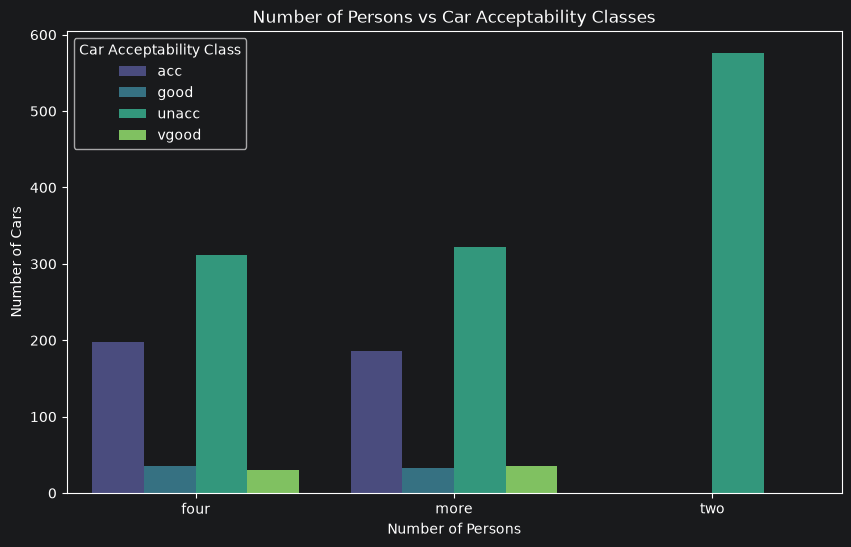

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt


grouped_data = df.groupby(['persons', 'car']).size().reset_index(name='appearances')

plt.figure(figsize=(10, 6))
sns.barplot(data=grouped_data,x='persons',y='appearances',hue='car',palette='viridis')

plt.title('Number of Persons vs Car Acceptability Classes')
plt.xlabel('Number of Persons')
plt.ylabel('Number of Cars')
plt.legend(title='Car Acceptability Class')

plt.show()

- The bar plot shows the relationship between the number of persons and car acceptability classes.
- We can see that the cars with two persons tend to be classified as unacc, while the cars with four and more persons tend to be classified as acc, good and vgood, which means that the number of persons is also an important feature in determining the acceptability of a car.

In [11]:
df_encoded = df.copy()

In [12]:
map_price={
    'low': 1,
    'med': 2,
    'high': 3,
    'vhigh': 4}
map_doors={
    'two': 2,
    'three': 3,
    'four': 4,
    '5more': 5}
map_persons={
    'two': 2,
    'four': 4,
    'more': 5}
map_lug_boot={
    'small': 1,
    'med': 2,
    'big': 3}
map_safety={
    'low': 1,
    'med': 2,
    'high': 3}
map_car={
    'unacc': 0,
    'acc': 1,
    'good': 2,
    'vgood': 3}

conf={
    'buying': map_price,
    'maint': map_price,
    'doors': map_doors,
    'persons': map_persons,
    'lug_boot': map_lug_boot,
    'safety': map_safety,
    'car': map_car
}
df_encoded=df_encoded.replace(conf)

In [13]:
df_encoded.head(10)

,buying,maint,doors,persons,lug_boot,safety,car
0,4,4,2,2,1,1,0
1,4,4,2,2,1,2,0
2,4,4,2,2,1,3,0
3,4,4,2,2,2,1,0
4,4,4,2,2,2,2,0
5,4,4,2,2,2,3,0
6,4,4,2,2,3,1,0
7,4,4,2,2,3,2,0
8,4,4,2,2,3,3,0
9,4,3,2,2,1,1,0


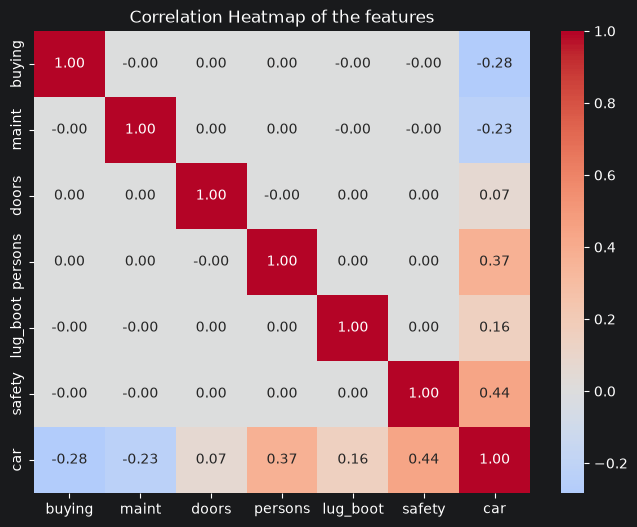

In [14]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title('Correlation Heatmap of the features')
plt.show()

- This heatmap shows the correlation between the features in the dataset.
- As expected the 'car' feature has the highest correlation with the 'safety' feature, which means that the safety level is the most important feature in determining the acceptability of a car.
- We can also see that the 'buying' and 'maint' features have a pretty high negative correlation with the 'car' feature, which means that the buying price and maintenance cost are also important features in determining the acceptability of a car.
- The person feature has also a high correlation with the 'car' feature, which means that the number of persons is also an important feature in determining the acceptability of a car.
- Because the features are not correlated with each other, we can't perform feature engineering to create new features from the existing ones, but we can use the existing features to build a model that can predict the acceptability of a car.

# 2. Data preprocessing

#### 2.1 Check for missing values

In [15]:
df.isnull().sum()


buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
car         0
dtype: int64

- The dataset has no null values so we don't have to complete the dataset.


#### 2.2 Encode the categorical feature

- Because I will apply SMOTE to solve the data imbalance problem I will use Ordinal Encoding.
- I choose Ordinal Encoding because the SMOTE alg. is based on Interpolation , One Hot encoding split the datas in more "binary" columns , beacuse of this the Interpolation is not possible.
- The Label Encoding use a similar alg for encoding the data but the labels will be random, fact that will confuse the model , a high atrib can get the label 1 and a low atrb 4, the model will interpret the low value as being more weighted than the high value which is not desirable.

In [16]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

def mapping(X):
    return X.copy().replace(conf)
pipeline = Pipeline([
    ('encoding', FunctionTransformer(mapping)),
    ('imputer', SimpleImputer(strategy='median')),
])




In [17]:
from sklearn.model_selection import train_test_split
X=df.drop('car', axis=1)
y=df['car'].map({'unacc': 0, 'acc': 1, 'good': 2, 'vgood': 3})
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y) # I used stratify for maintaining the distribution of classes in both sets

In [18]:
X_train_enc =pipeline.fit_transform(X_train)
smote = SMOTE(random_state=42)
X_train_prepared, y_train_prepared = smote.fit_resample(X_train_enc, y_train)
X_test_prepared=pipeline.transform(X_test)

- In this case because we use SMOTE and resample for the pipeline we us fit_resample for both X and y
- We use fit_resample for both because SMOTE will add new values to the dataset to balance it.

In [19]:
print(" Without Resampling ")
print(y_train.value_counts())

print("\n With SMOTE Resampling ")
print(y_train_prepared.value_counts())

 Without Resampling 
car
0    968
1    307
2     55
3     52
Name: count, dtype: int64

 With SMOTE Resampling 
car
1    968
0    968
2    968
3    968
Name: count, dtype: int64


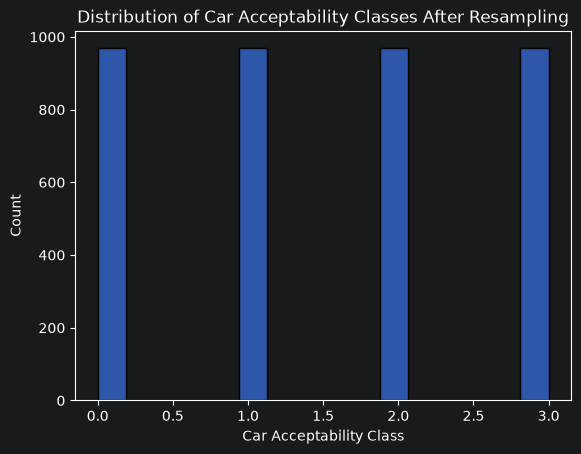

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(y_train_prepared, bins="auto")
plt.title('Distribution of Car Acceptability Classes After Resampling')
plt.xlabel('Car Acceptability Class')
plt.ylabel('Count')
plt.show()

- We can see that the distribution of classes is now balanced after resampling.
- This is important for ensuring that the model does not become biased towards the majority class.

#  3. Models Training

In [21]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
def tuning(model, params, X_train, y_train, type="grid"):

    if type == "grid":
        search = GridSearchCV(model, params, cv=5, scoring='accuracy', n_jobs=-1)
    else:
        search = RandomizedSearchCV(model, params, n_iter=10, cv=5, scoring='accuracy', n_jobs=-1, random_state=42)

    search.fit(X_train, y_train)
    print(f"best train acc: {search.best_score_ * 100:.2f}%")
    print(f"best params:\n{search.best_params_}")


    return search.best_estimator_

- Because we have to perform tuning on the every model hyperparameters I developed this tuning function to chose from the 2 tuning strategies .

#### 3.1 Logistic Regression Classifier

In [22]:
from sklearn.linear_model import LogisticRegression

log_reg= LogisticRegression(max_iter=2000, random_state=42)
log_reg.fit(X_train_prepared, y_train_prepared)

param_grid = [
    {'solver': ['saga'], 'penalty': ['elasticnet'], 'C': [0.01, 0.1, 1, 10, 100], 'l1_ratio': [0.2, 0.5, 0.8]},
{'solver': ['saga'], 'penalty': ['l1', 'l2'], 'C': [0.01, 0.1, 1, 10, 100]}
]

best_log_reg_CV=tuning(log_reg, param_grid, X_train_prepared, y_train_prepared, type="grid")

best_log_reg_R=tuning(log_reg, param_grid, X_train_prepared, y_train_prepared, type="random")

y_pred_lr= log_reg.predict(X_test_prepared)
y_pred_lr_R=best_log_reg_R.predict(X_test_prepared)
y_pred_lr_CV=best_log_reg_CV.predict(X_test_prepared)


C:\Dev\Practica-AI\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


best train acc: 90.75%
best params:
{'C': 1, 'l1_ratio': 0.5, 'penalty': 'elasticnet', 'solver': 'saga'}


C:\Dev\Practica-AI\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


best train acc: 90.68%
best params:
{'solver': 'saga', 'penalty': 'elasticnet', 'l1_ratio': 0.8, 'C': 1}


In [23]:
from sklearn.metrics import accuracy_score

acc_base=accuracy_score(y_test, y_pred_lr)
acc_CV=accuracy_score(y_test, y_pred_lr_CV)
acc_R=accuracy_score(y_test, y_pred_lr_R)

print(f"1. No tuning : {acc_base * 100:.2f}%")
print(f"2. Random Search tuning:      {acc_R * 100:.2f}%")
print(f"3. Grid Search tuning:        {acc_CV * 100:.2f}%")


1. No tuning : 83.82%
2. Random Search tuning:      84.10%
3. Grid Search tuning:        83.82%


- As we can see from the accuracy scores, the tuned model using Random Search perform better than the base model and the CVSearch model.
- Accuracy is not the metric we should focus on for imbalanced datasets but it's a good proof that the hyperparameters tuning improved the model's performance.

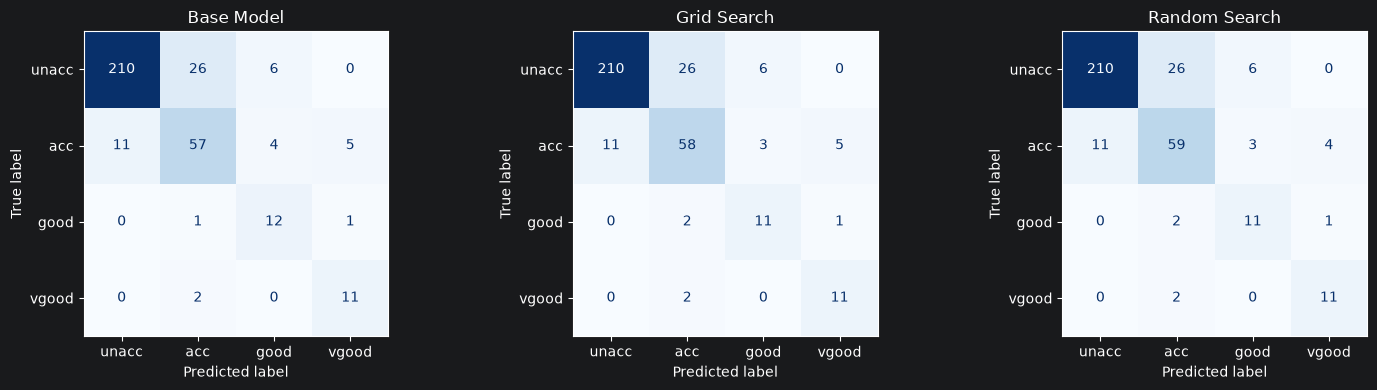

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

class_labels = ['unacc', 'acc', 'good', 'vgood']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr,display_labels=class_labels,cmap="Blues", ax=axes[0],colorbar=False)
axes[0].set_title("Base Model")

ConfusionMatrixDisplay.from_predictions( y_test,y_pred_lr_CV, display_labels=class_labels,cmap="Blues",ax=axes[1],colorbar=False)
axes[1].set_title("Grid Search")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr_R,display_labels=class_labels,cmap="Blues",
    ax=axes[2],colorbar=False)
axes[2].set_title("Random Search")

plt.tight_layout()
plt.show()

- As observed, the Logistic Regression models perform almost identically, regardless of the hyperparameter tuning applied.
- This occurs because Logistic Regression is a fundamentally linear classifier. Its structural simplicity limits its capacity to capture highly complex, non-linear relationships within the dataset, causing the metrics to hit a natural performance ceiling that tuning alone cannot surpass.
- However the confusion matrix shows some differences in the classification of specific classes.
- We can see that the models perfroms well, showing in principle the good category but there is some miss clasifications which is normal for a linear model that has big limitations.

#### 3.2 Decision Tree

In [25]:
from sklearn.tree import DecisionTreeClassifier

decision_tree=DecisionTreeClassifier(random_state=42,max_depth=5)
decision_tree.fit(X_train_prepared, y_train_prepared)

param_grid={
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth':[None, 5,10,20],
    'min_samples_split':[2, 5, 10, 20],
    'min_samples_leaf':[2, 5, 10, 20],
}

decision_tree_CV=tuning(decision_tree, param_grid, X_train_prepared, y_train_prepared,type="grid")
decision_tree_R=tuning(decision_tree, param_grid, X_train_prepared, y_train_prepared,type="random")

y_pred_dt=decision_tree.predict(X_test_prepared)
y_pred_dt_CV=decision_tree_CV.predict(X_test_prepared)
y_pred_dt_R=decision_tree_R.predict(X_test_prepared)

best train acc: 98.86%
best params:
{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'splitter': 'best'}
best train acc: 98.66%
best params:
{'splitter': 'best', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': 20, 'criterion': 'entropy'}


In [26]:
acc_base=accuracy_score(y_test, y_pred_dt)
acc_CV=accuracy_score(y_test, y_pred_dt_CV)
acc_R=accuracy_score(y_test, y_pred_dt_R)

print(f"1. No tuning : {acc_base * 100:.2f}%")
print(f"2. Random Search tuning:      {acc_R * 100:.2f}%")
print(f"3. Grid Search tuning:        {acc_CV * 100:.2f}%")


1. No tuning : 87.86%
2. Random Search tuning:      97.11%
3. Grid Search tuning:        97.11%


- Even if the acc is not our final metric we can see that the DT models performed better than the Regression as expected.
- From acc we can see that the base model with max_depth=5 and without any tuning performed a bit lower than the tuned models , this phenomenon is due to the depth limitation .

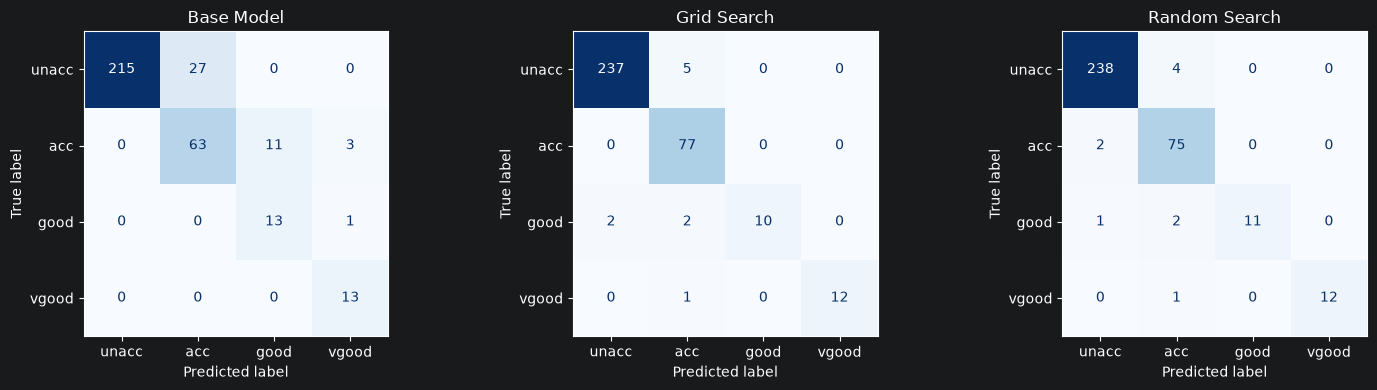

In [27]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

class_labels = ['unacc', 'acc', 'good', 'vgood']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt,display_labels=class_labels,cmap="Blues", ax=axes[0],colorbar=False)
axes[0].set_title("Base Model")

ConfusionMatrixDisplay.from_predictions( y_test,y_pred_dt_CV, display_labels=class_labels,cmap="Blues",ax=axes[1],colorbar=False)
axes[1].set_title("Grid Search")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt_R,display_labels=class_labels,cmap="Blues",
    ax=axes[2],colorbar=False)
axes[2].set_title("Random Search")

plt.tight_layout()
plt.show()

- We can see from the confusion matrixes that the models performed really good on the test set.
- The base model miss classified only 42 values wich is an outstanding performance considering the limited depth we set.
- At first when I saw the acc on the train set I thought that we will have an over-fitting phenomenon on the train set but actually the models performed really well on the test set.
- The miss classifications for the tuned models are really few , so at a first glance the models performed really well.


#### 3.3 SVM

In [28]:
from sklearn.svm import SVC

svm= SVC(random_state=42,probability=True)
svm.fit(X_train_prepared, y_train_prepared)


param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

best_svm_CV = tuning(svm, param_grid, X_train_prepared, y_train_prepared, type="grid")

best_svm_R = tuning(svm, param_grid, X_train_prepared, y_train_prepared, type="random")

y_pred_svm = svm.predict(X_test_prepared)
y_pred_svm_R = best_svm_R.predict(X_test_prepared)
y_pred_svm_CV = best_svm_CV.predict(X_test_prepared)

C:\Dev\Practica-AI\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Dev\Practica-AI\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


best train acc: 99.66%
best params:
{'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}


C:\Dev\Practica-AI\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


best train acc: 99.66%
best params:
{'kernel': 'rbf', 'gamma': 'auto', 'C': 10}


- We can see that now both search methods gave us the same models so we will test only one because the models are exactly the same.
- The models are the same probably because of the small search space, I chosed a small search space to make the search faster and less power cosnuming because SVM is a big algorithm.

In [29]:
acc_base=accuracy_score(y_test, y_pred_svm)
acc_tuned=accuracy_score(y_test, y_pred_svm_CV)


print(f"1. No tuning : {acc_base * 100:.2f}%")
print(f"2. Tuned:      {acc_tuned * 100:.2f}%")



1. No tuning : 97.11%
2. Tuned:      98.84%


- Again the tuning gives us a model better than the base one but this time the difference is small.
- The difference is that small maybe because of the small search space.


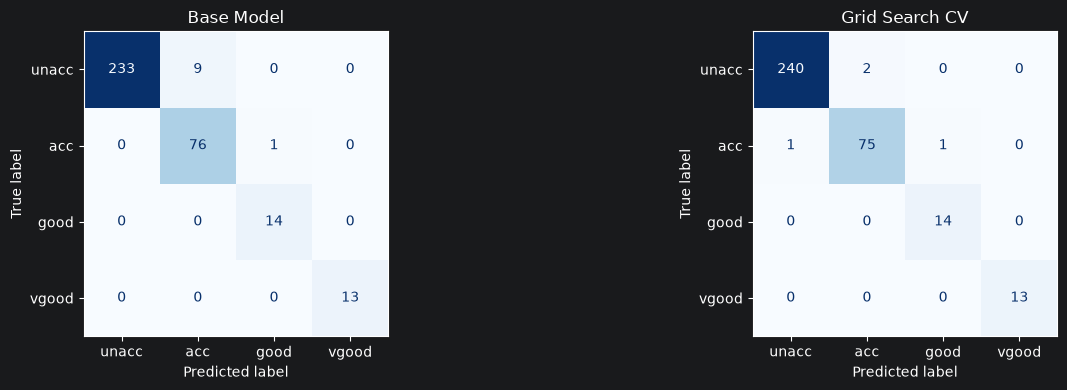

In [30]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

class_labels = ['unacc', 'acc', 'good', 'vgood']

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm,display_labels=class_labels,cmap="Blues", ax=axes[0],colorbar=False)
axes[0].set_title("Base Model")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm_CV, display_labels=class_labels,cmap="Blues",ax=axes[1],colorbar=False)
axes[1].set_title("Grid Search CV")

plt.tight_layout()
plt.show()



- As we can see both models classified the car acceptability very well.
- The SVM model has better performances than the other ones because of it's complexity and because our datas are not very large and different fact that made the work of the SVM model easier.

#### 3.4 K-Nearest Neighbors (KNN)

In [31]:
from sklearn.neighbors import KNeighborsClassifier

knn=KNeighborsClassifier()
knn.fit(X_train_prepared, y_train_prepared)

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn_CV=tuning(knn, param_grid, X_train_prepared, y_train_prepared, type="grid")
y_pred_knn = knn.predict(X_test_prepared)
y_pred_knn_CV = knn_CV.predict(X_test_prepared)


best train acc: 99.12%
best params:
{'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}


In [32]:
acc_base=accuracy_score(y_test, y_pred_knn)
acc_CV=accuracy_score(y_test, y_pred_knn_CV)
print(f"1. No tuning : {acc_base * 100:.2f}%")
print(f"2. Tuned:      {acc_CV * 100:.2f}%")

1. No tuning : 95.38%
2. Tuned:      91.62%


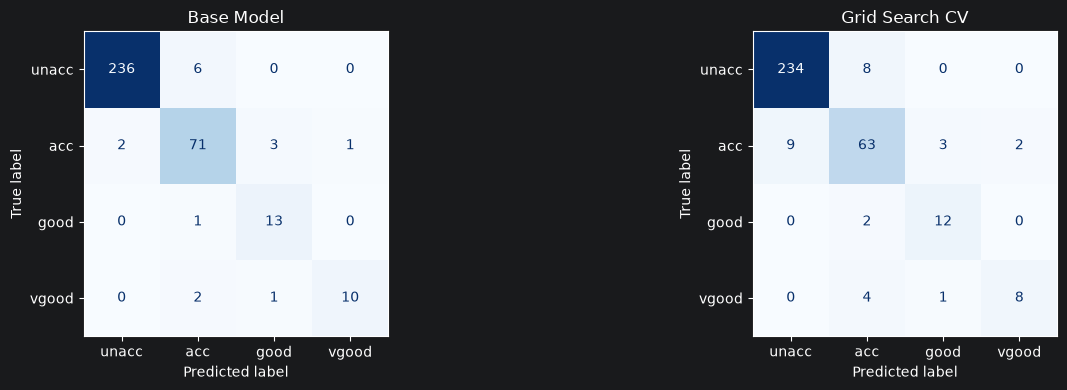

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

class_labels = ['unacc', 'acc', 'good', 'vgood']

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn,display_labels=class_labels,cmap="Blues", ax=axes[0],colorbar=False)
axes[0].set_title("Base Model")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn_CV, display_labels=class_labels,cmap="Blues",ax=axes[1],colorbar=False)
axes[1].set_title("Grid Search CV")

plt.tight_layout()
plt.show()



- As we can see both models classified the car acceptability very well.
- The tuned model showed a bit of overfitting on the training set but in the end it's predictions are not at all
- The difference between models comes probably from the neighbors param , the base model has 5 which is a robust choice and prevent overfitting testing more 'opinions'


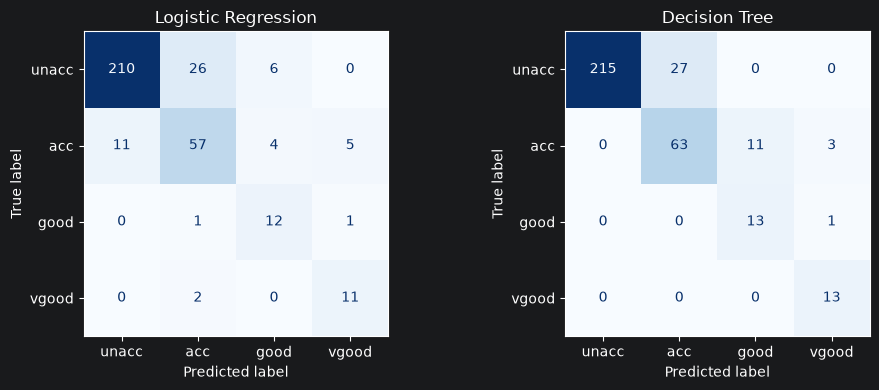

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    display_labels=class_labels,
    cmap="Blues",
    ax=axes[0],
    colorbar=False
)
axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_dt,
    display_labels=class_labels,
    cmap="Blues",
    ax=axes[1],
    colorbar=False
)
axes[1].set_title("Decision Tree")

plt.tight_layout()
plt.show()

- The confusion matrices compare the baseline (untuned) Logistic Regression and Decision Tree models.
- Both models correctly classify most samples, as indicated by the high values along the main diagonal.
- However, the Decision Tree produces fewer misclassifications overall, particularly for the good and vgood classes, demonstrating a better ability to separate the four car acceptability categories before hyperparameter tuning

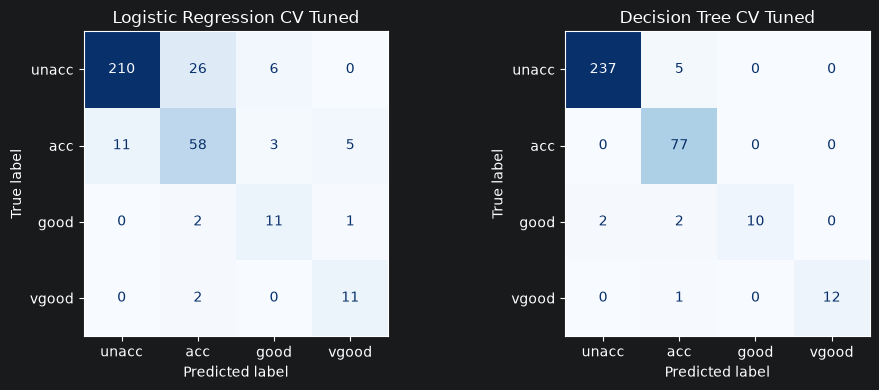

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr_CV,
    display_labels=class_labels,
    cmap="Blues",
    ax=axes[0],
    colorbar=False
)
axes[0].set_title("Logistic Regression CV Tuned")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_dt_CV,
    display_labels=class_labels,
    cmap="Blues",
    ax=axes[1],
    colorbar=False
)
axes[1].set_title("Decision Tree CV Tuned")

plt.tight_layout()
plt.show()

- The confusion matrices compare the cross-validation tuned Logistic Regression and Decision Tree models.
- Both models achieve strong classification performance, with most predictions correctly placed along the main diagonal.
- However, the tuned Decision Tree produces noticeably fewer misclassifications, particularly for the unacc and acc classes, while maintaining good performance on the minority classes (good and vgood).
- Overall, hyperparameter tuning further improves the Decision Tree, making it the stronger classifier compared to the tuned Logistic Regression.

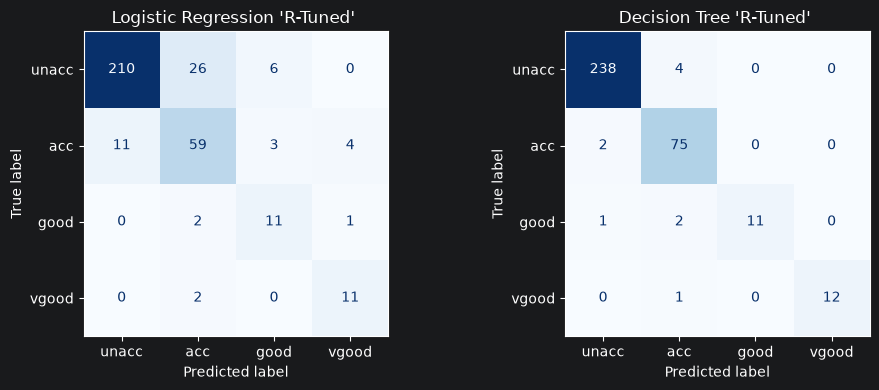

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr_R,
    display_labels=class_labels,
    cmap="Blues",
    ax=axes[0],
    colorbar=False
)
axes[0].set_title("Logistic Regression 'R-Tuned' ")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_dt_R,
    display_labels=class_labels,
    cmap="Blues",
    ax=axes[1],
    colorbar=False
)
axes[1].set_title("Decision Tree 'R-Tuned' ")

plt.tight_layout()
plt.show()

- The confusion matrices compare the Random Search tuned Logistic Regression and Decision Tree models.
- While both models correctly classify the majority of samples, the Random Search tuned Decision Tree produces noticeably fewer misclassifications across most classes, particularly for unacc and acc.
- The Logistic Regression model still struggles with several confusions between unacc and acc, whereas the Decision Tree achieves a cleaner separation between classes.
- These observations are consistent with the evaluation metrics, confirming that the Random Search tuned Decision Tree outperforms the Random Search tuned Logistic Regression.

## Training Conlusions
- I tested these 4 models because every one of the models works on a different algorithm.
- Testing I saw how different under the hood algorithm can change base performances.
- On every model I tried with GridSearch or RandomSearch to obtain the best model.
- The best performances comes from SVM model. Due to model high mathematical complexity it's predictions we're really on point.
- The second model that gave us great base performances was Decision Trees, based on searching the best 'question' to ask for classifying correctly.
- On the KNN and Decision Tree models there may be signs of overfitting but we will check it on the next ticket , when testing real deal metrics :))

## 4. Metrics Evaluation

In [37]:
from sklearn.metrics import accuracy_score, classification_report

def metrics(model, X_test, y_test, model_name='Model'):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"Metrics for {model_name}:")
    print(f"  Accuracy: {acc * 100:.2f}%\n")

    print("Classification Report (Per-class Precision, Recall, F1):")
    print(classification_report(y_test, y_pred, target_names=["unacc", "acc", "good", "vgood"]))

#### 4.1 Logistic Regression

- Base Model

In [38]:
metrics(log_reg,X_test_prepared,y_test,"Base Logistic Regression")

Metrics for Base Logistic Regression:
  Accuracy: 83.82%

Classification Report (Per-class Precision, Recall, F1):
              precision    recall  f1-score   support

       unacc       0.95      0.87      0.91       242
         acc       0.66      0.74      0.70        77
        good       0.55      0.86      0.67        14
       vgood       0.65      0.85      0.73        13

    accuracy                           0.84       346
   macro avg       0.70      0.83      0.75       346
weighted avg       0.86      0.84      0.84       346



- The Logistic Regression model achieved 83.82% accuracy on the test set.
- According to the classification report, the weighted F1-score is 0.84 and the macro F1-score is 0.75, showing decent overall performance but weaker results on the minority classes.
- The model performs well on unacc, but the lower precision and recall for acc, good, and vgood indicate that Logistic Regression still struggles with the more complex class boundaries in this dataset.


In [39]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import RocCurveDisplay, roc_auc_score
import matplotlib.pyplot as plt

def plot_roc(model, X_test, y_test, model_name, ax=None):

    class_names = ['unacc', 'acc', 'good', 'vgood']
    classes = sorted(y_test.unique())

    y_test_bin = label_binarize(y_test, classes=classes)
    y_prob = model.predict_proba(X_test)

    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
        created_fig = True

    for i, class_name in enumerate(class_names):

        auc_score = roc_auc_score(
            y_test_bin[:, i],
            y_prob[:, i]
        )

        print(f"{class_name} AUC: {auc_score:.3f}")

        RocCurveDisplay.from_predictions(
            y_test_bin[:, i],
            y_prob[:, i],
            name=class_name,
            ax=ax
        )

    ax.plot([0, 1], [0, 1], 'k--')
    ax.set_title(f"ROC Curve - {model_name}")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")

    if created_fig:
        plt.show()

unacc AUC: 0.955
acc AUC: 0.922
good AUC: 0.986
vgood AUC: 0.994


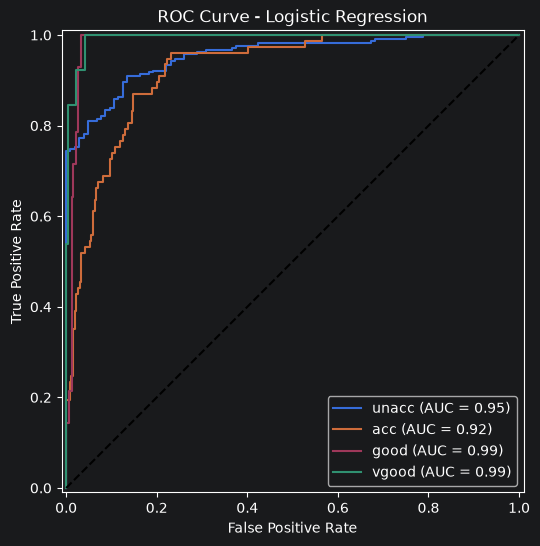

In [40]:
plot_roc(log_reg,X_test_prepared,y_test,"Logistic Regression")

- The Logistic Regression model achieved an accuracy of 83.82%, correctly classifying approximately 84% of the test samples.
- Although the accuracy is lower than the AUC values, this is expected in a multiclass classification problem.
- Accuracy only measures whether the final predicted class is correct, while the ROC curves and AUC evaluate the model's ability to distinguish between classes based on prediction probabilities.
- The ROC curves are close to the top-left corner, and all AUC values are above 0.90, indicating excellent discriminative performance.
- The best results are obtained for class vgood and good and the acc class is the most difficult to distinguish. Overall, the model demonstrates good classification performance and strong class separation

- Random Search Tuned Model

In [41]:
metrics(best_log_reg_R,X_test_prepared,y_test,"Logistic Regression Tuned")

Metrics for Logistic Regression Tuned:
  Accuracy: 84.10%

Classification Report (Per-class Precision, Recall, F1):
              precision    recall  f1-score   support

       unacc       0.95      0.87      0.91       242
         acc       0.66      0.77      0.71        77
        good       0.55      0.79      0.65        14
       vgood       0.69      0.85      0.76        13

    accuracy                           0.84       346
   macro avg       0.71      0.82      0.76       346
weighted avg       0.86      0.84      0.85       346



- Hyperparameter tuning produced only a small improvement for Logistic Regression, raising the accuracy to 84.10%.
- The classification report shows a weighted F1-score of 0.85 and a macro F1-score of 0.76, with modest gains in acc, good, and vgood.
- This confirms that the tuned Logistic Regression model is slightly better than the baseline, but the improvement is still limited by the linear nature of the classifier.


unacc AUC: 0.955
acc AUC: 0.923
good AUC: 0.986
vgood AUC: 0.994


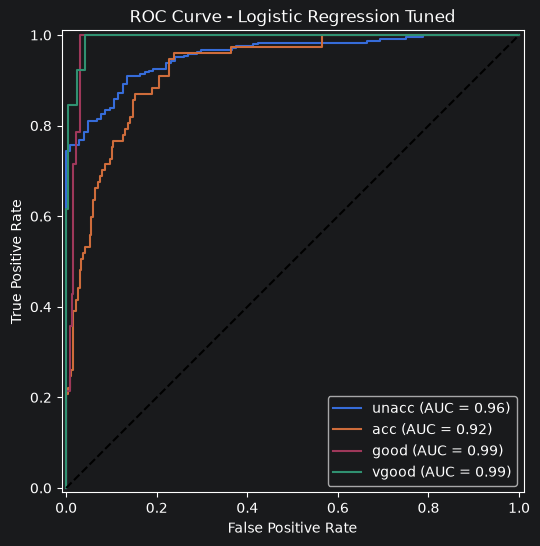

In [42]:
plot_roc(best_log_reg_R,X_test_prepared,y_test,"Logistic Regression Tuned")

- The ROC curves of the tuned Logistic Regression model are almost identical to those of the baseline model.
- All AUC values remain above 0.92, indicating excellent class discrimination.
- Only a negligible improvement is observed for class good (AUC increased from 0.922 to 0.923), while the remaining classes maintain the same AUC values.
- These results confirm that hyperparameter tuning provides only a marginal improvement, suggesting that the default Logistic Regression configuration was already close to optimal for this dataset.

#### 4.2 Decision Tree

- Base model

In [43]:
metrics(decision_tree,X_test_prepared,y_test,"Decision Tree")

Metrics for Decision Tree:
  Accuracy: 87.86%

Classification Report (Per-class Precision, Recall, F1):
              precision    recall  f1-score   support

       unacc       1.00      0.89      0.94       242
         acc       0.70      0.82      0.75        77
        good       0.54      0.93      0.68        14
       vgood       0.76      1.00      0.87        13

    accuracy                           0.88       346
   macro avg       0.75      0.91      0.81       346
weighted avg       0.91      0.88      0.89       346



- The Decision Tree model outperforms Logistic Regression across the classification report, reaching 87.86% accuracy.
- It also achieves a weighted F1-score of 0.89 and a macro F1-score of 0.81, which indicates stronger overall class separation.
- The model performs especially well on unacc and vgood, while good still shows some imbalance between precision and recall, but overall the tree captures the non-linear structure of the dataset much better than Logistic Regression.


unacc AUC: 0.982
acc AUC: 0.955
good AUC: 0.985
vgood AUC: 0.994


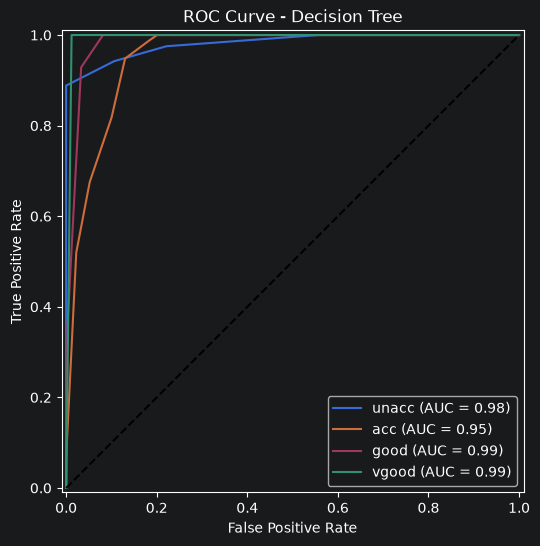

In [44]:
plot_roc(decision_tree,X_test_prepared,y_test,"Decision Tree")

-  The ROC curves indicate excellent class discrimination, with AUC values ranging from 0.955 to 0.994.
- Compared to Logistic Regression, the Decision Tree shows noticeable improvements for unacc and acc clases, while maintaining similarly high performance for classes good and vgood.
- These results demonstrate that the Decision Tree is better suited for capturing the non-linear decision rules present in the dataset.

- Tuned Model

In [45]:
metrics(decision_tree_CV,X_test_prepared,y_test,"Decision Tree Tuned")

Metrics for Decision Tree Tuned:
  Accuracy: 97.11%

Classification Report (Per-class Precision, Recall, F1):
              precision    recall  f1-score   support

       unacc       0.99      0.98      0.99       242
         acc       0.91      1.00      0.95        77
        good       1.00      0.71      0.83        14
       vgood       1.00      0.92      0.96        13

    accuracy                           0.97       346
   macro avg       0.97      0.90      0.93       346
weighted avg       0.97      0.97      0.97       346



- Hyperparameter tuning significantly improved the Decision Tree model, increasing the accuracy to 97.11%.
- The classification report shows weighted precision/recall/F1 around 0.97 and a macro F1-score of 0.93, confirming excellent overall performance.
- The tuned tree classifies unacc, acc, and vgood extremely well, while good has lower recall than the other classes, but the model is still one of the strongest results in the notebook.


unacc AUC: 0.995
acc AUC: 0.992
good AUC: 0.928
vgood AUC: 1.000


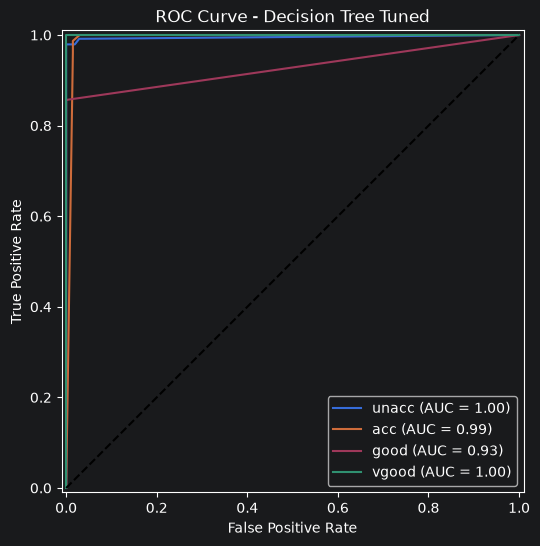

In [46]:
plot_roc(decision_tree_CV,X_test_prepared,y_test,"Decision Tree Tuned")

- The ROC analysis also confirms excellent discriminative performance, with AUC values of 0.995, 0.992, 0.928, and 1.000 for the four classes.
- Most classes show a noticeable improvement in AUC, while class good experiences a slight decrease despite the higher overall classification performance.
- Overall, the tuned Decision Tree demonstrates excellent predictive capability and is the best-performing model evaluated so far.

#### 4.3 SVM

- Base model

In [47]:
metrics(svm,X_test_prepared,y_test,"Support Vector Machine")

Metrics for Support Vector Machine:
  Accuracy: 97.11%

Classification Report (Per-class Precision, Recall, F1):
              precision    recall  f1-score   support

       unacc       1.00      0.96      0.98       242
         acc       0.89      0.99      0.94        77
        good       0.93      1.00      0.97        14
       vgood       1.00      1.00      1.00        13

    accuracy                           0.97       346
   macro avg       0.96      0.99      0.97       346
weighted avg       0.97      0.97      0.97       346



- The Support Vector Machine achieved 97.11% accuracy on the test set.
- Its classification report shows weighted precision/recall/F1 of 0.97 and a macro F1-score of 0.97, indicating excellent and very balanced performance across classes.
- The model predicts unacc, acc, good, and vgood very reliably, making SVM one of the best-performing classifiers in this study.


unacc AUC: 0.997
acc AUC: 0.992
good AUC: 0.998
vgood AUC: 1.000


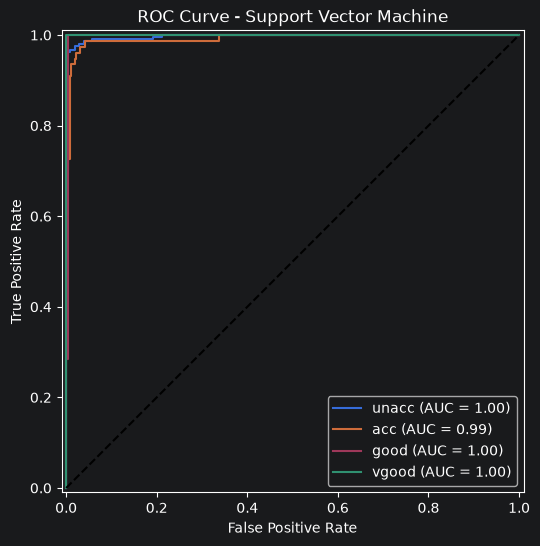

In [48]:
plot_roc(svm,X_test_prepared,y_test,"Support Vector Machine")

- The ROC curves are very close to the top-left corner, with AUC values ranging from 0.992 to 1.000, indicating almost perfect class discrimination.
- Compared to the tuned Decision Tree, the SVM provides similar overall performance while achieving a noticeably higher AUC for class good, demonstrating superior class separation.
 - Overall, the SVM is one of the best-performing models evaluated in this study.

- SVM Tuned

In [49]:
metrics(best_svm_R,X_test_prepared,y_test,"Support Vector Machine Tuned")

Metrics for Support Vector Machine Tuned:
  Accuracy: 98.84%

Classification Report (Per-class Precision, Recall, F1):
              precision    recall  f1-score   support

       unacc       1.00      0.99      0.99       242
         acc       0.97      0.97      0.97        77
        good       0.93      1.00      0.97        14
       vgood       1.00      1.00      1.00        13

    accuracy                           0.99       346
   macro avg       0.98      0.99      0.98       346
weighted avg       0.99      0.99      0.99       346



- Hyperparameter tuning further improved the Support Vector Machine, increasing the accuracy to 98.84%.
- The classification report shows weighted precision/recall/F1 of 0.99 and a macro F1-score of 0.98, which is the best overall performance among the evaluated models.
- The tuned SVM performs exceptionally well on every class, with near-perfect scores for `unacc`, acc, good, and vgood.


unacc AUC: 1.000
acc AUC: 0.999
good AUC: 1.000
vgood AUC: 1.000


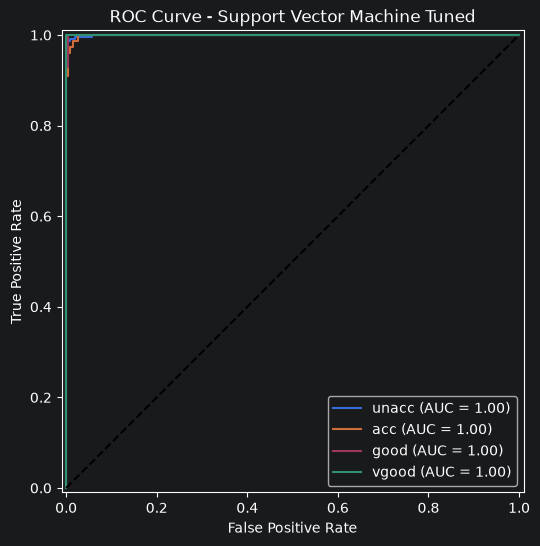

In [50]:
plot_roc(best_svm_R,X_test_prepared,y_test,"Support Vector Machine Tuned")

- The ROC curves are almost perfectly aligned with the top-left corner, and the AUC values range from 0.999 to 1.000, demonstrating nearly perfect class discrimination.
- These results confirm that hyperparameter tuning significantly enhanced the SVM model, making it the most accurate and reliable classifier for the dataset.

#### 4.4 KNN

- Base Model

In [51]:
metrics(knn,X_test_prepared,y_test,"KNN")

Metrics for KNN:
  Accuracy: 95.38%

Classification Report (Per-class Precision, Recall, F1):
              precision    recall  f1-score   support

       unacc       0.99      0.98      0.98       242
         acc       0.89      0.92      0.90        77
        good       0.76      0.93      0.84        14
       vgood       0.91      0.77      0.83        13

    accuracy                           0.95       346
   macro avg       0.89      0.90      0.89       346
weighted avg       0.96      0.95      0.95       346



- The K-Nearest Neighbors model achieved 95.38% accuracy on the test set.
- Its classification report shows weighted precision/recall/F1 of 0.95/0.95/0.95 and a macro F1-score of 0.89, which confirms strong overall performance.
- The model works especially well for unacc and acc, but vgood has slightly lower recall, so KNN remains effective while still trailing the tuned Decision Tree and tuned SVM.


unacc AUC: 0.996
acc AUC: 0.957
good AUC: 0.992
vgood AUC: 0.957


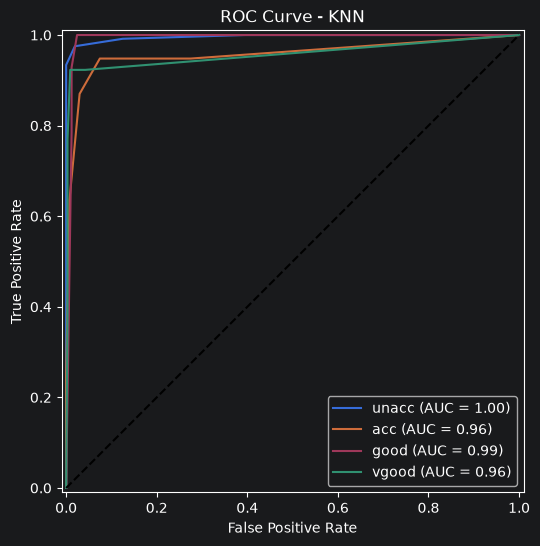

In [52]:
plot_roc(knn,X_test_prepared,y_test,"KNN")

- The ROC curves are close to the top-left corner, indicating good discriminative ability across all classes. However, compared to the Support Vector Machine, KNN achieved lower AUC values for classes acc and vgood, resulting in slightly lower overall classification performance.
- Despite this, KNN remains an effective classifier.

- Tuned Model

In [53]:
metrics(knn_CV,X_test_prepared,y_test,"KNN Tuned")

Metrics for KNN Tuned:
  Accuracy: 91.62%

Classification Report (Per-class Precision, Recall, F1):
              precision    recall  f1-score   support

       unacc       0.96      0.97      0.96       242
         acc       0.82      0.82      0.82        77
        good       0.75      0.86      0.80        14
       vgood       0.80      0.62      0.70        13

    accuracy                           0.92       346
   macro avg       0.83      0.81      0.82       346
weighted avg       0.92      0.92      0.92       346



- Hyperparameter tuning did not improve the K-Nearest Neighbors model on the test set, which decreased to 91.62% accuracy.
- The classification report shows weighted precision/recall/F1 of 0.92 and a macro F1-score of 0.82, which is lower than the default KNN configuration.
- Although the tuned model fits the training data very well, the weaker test performance and lower vgood recall indicate poorer generalization, so the default KNN model is still the better choice.


unacc AUC: 0.986
acc AUC: 0.942
good AUC: 0.996
vgood AUC: 0.992


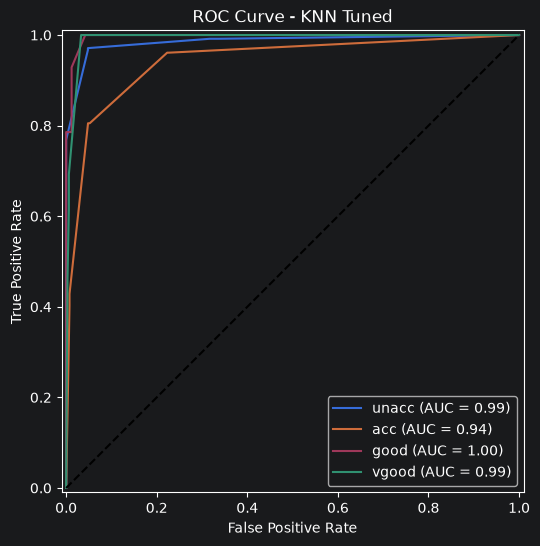

In [54]:
plot_roc(knn_CV,X_test_prepared,y_test,"KNN Tuned")

- The tuned K-Nearest Neighbors model achieved AUC values between 0.942 and 0.996, indicating good class discrimination.
- Compared to the default KNN model, the AUC values improved for classes good and vgood, while they decreased for classes unacc and acc.
- Despite these improvements for individual classes, the overall classification performance declined, with the accuracy dropping from 95.38% to 91.62%.
- Therefore, the default KNN model provides better overall performance and remains the preferred configuration for this dataset.

#### LR vs DT

unacc AUC: 0.955
acc AUC: 0.922
good AUC: 0.986
vgood AUC: 0.994
unacc AUC: 0.982
acc AUC: 0.955
good AUC: 0.985
vgood AUC: 0.994


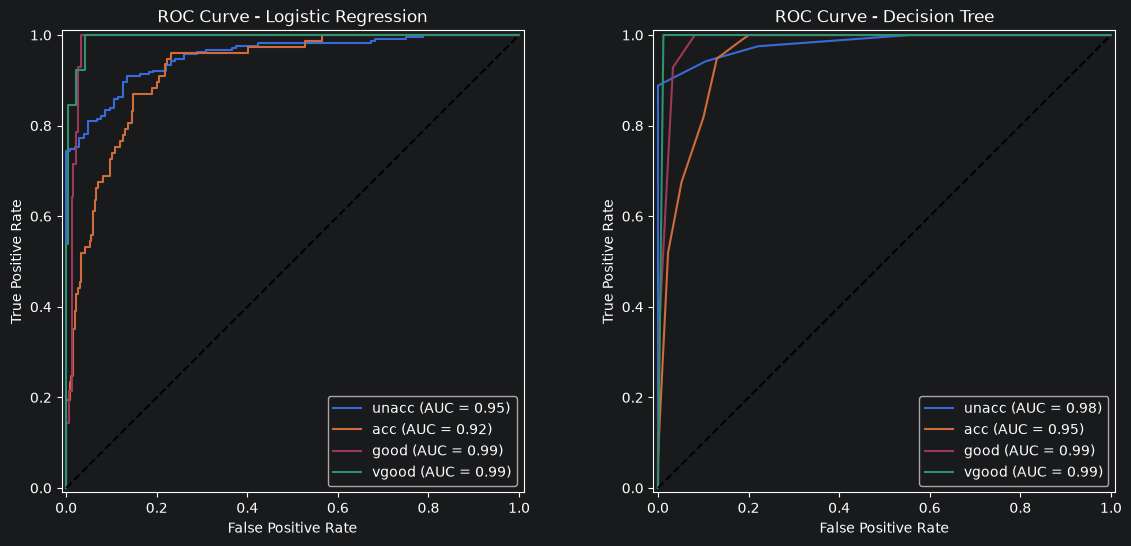

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

plot_roc(log_reg, X_test_prepared, y_test, "Logistic Regression",axes[0])

plot_roc(decision_tree, X_test_prepared, y_test, "Decision Tree",axes[1])


- The ROC curves show that both Logistic Regression and Decision Tree (untuned) perform well, with curves positioned close to the top-left corner and high AUC values for all classes.
- However, the Decision Tree consistently achieves higher AUC scores, especially for the unacc and acc classes, indicating better class separability.
- This is also reflected in its higher Accuracy and F1-Score, making the Decision Tree the stronger baseline model before hyperparameter tuning.

unacc AUC: 0.955
acc AUC: 0.923
good AUC: 0.986
vgood AUC: 0.994
unacc AUC: 0.995
acc AUC: 0.992
good AUC: 0.928
vgood AUC: 1.000


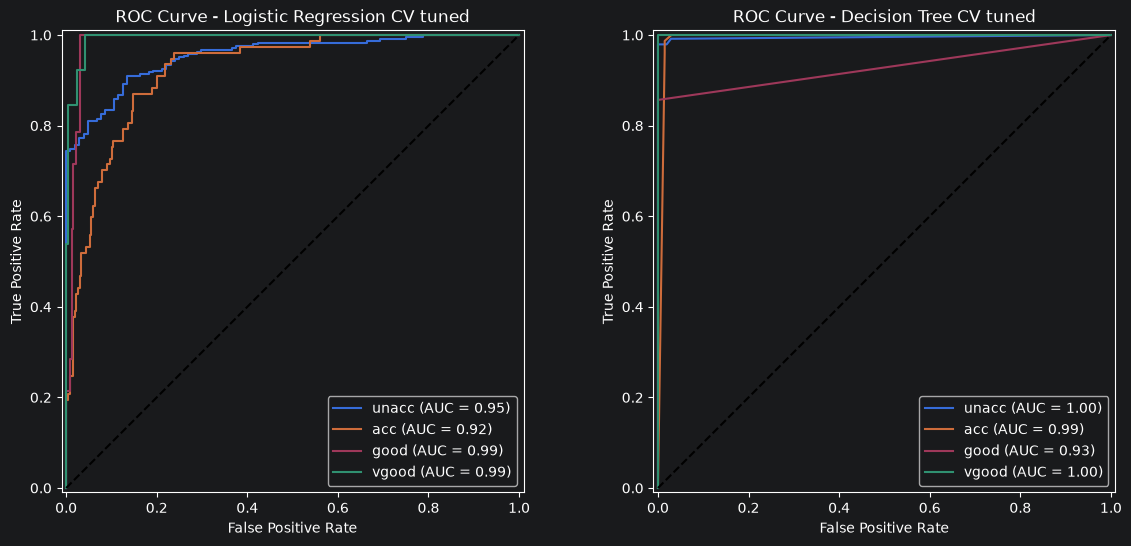

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

plot_roc(best_log_reg_CV, X_test_prepared, y_test, "Logistic Regression CV tuned",axes[0])

plot_roc(decision_tree_CV, X_test_prepared, y_test, "Decision Tree CV tuned",axes[1])


- After hyperparameter tuning using Cross-Validation, both models achieved high ROC-AUC values across all classes, indicating strong discriminative performance.
- The tuned Decision Tree outperformed the tuned Logistic Regression for the unacc, acc, and vgood classes, while Logistic Regression achieved a higher AUC only for the good class (0.986 vs 0.928).
- Combined with its superior Accuracy and F1-Score, the tuned Decision Tree remains the better overall classifier after Cross-Validation tuning.

unacc AUC: 0.955
acc AUC: 0.923
good AUC: 0.986
vgood AUC: 0.994
unacc AUC: 0.995
acc AUC: 0.991
good AUC: 0.928
vgood AUC: 1.000


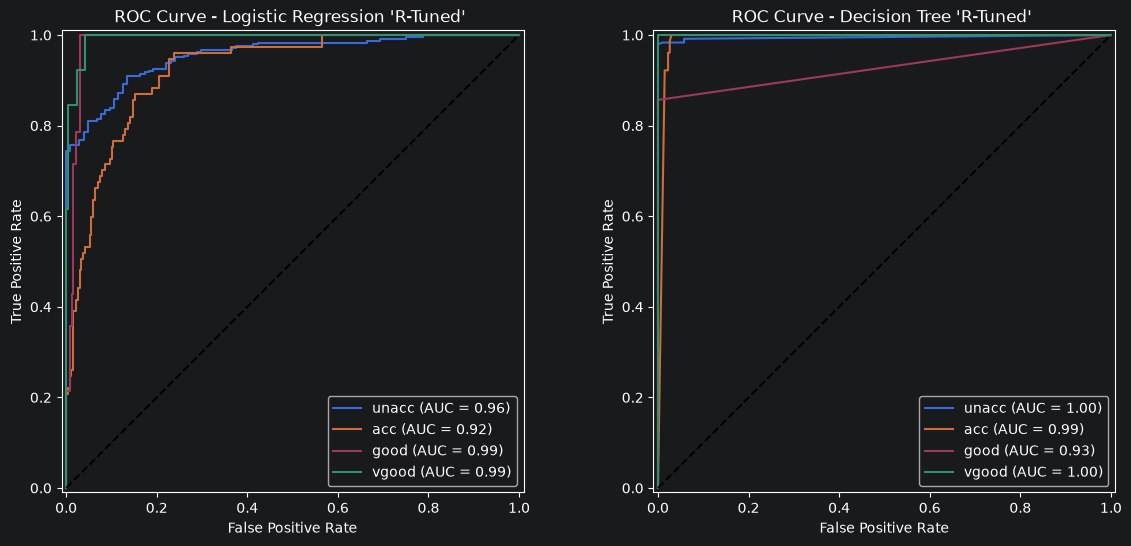

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

plot_roc(best_log_reg_R, X_test_prepared, y_test, "Logistic Regression 'R-Tuned' ",axes[0])

plot_roc(decision_tree_R, X_test_prepared, y_test, "Decision Tree 'R-Tuned' ",axes[1])


- After hyperparameter tuning using Random Search, both models achieved high ROC-AUC values, demonstrating strong class discrimination.
- The tuned Decision Tree outperformed the tuned Logistic Regression for the unacc, acc, and vgood classes, while Logistic Regression achieved a higher AUC only for the good class (0.986 vs 0.928).
- Overall, considering both the ROC-AUC values and the evaluation metrics, the Random Search tuned Decision Tree remains the better-performing model.

#### LR vs DT final conclusion
- Logistic Regression and Decision Tree were evaluated using Accuracy, Precision, Recall, F1-score, Confusion Matrices, and ROC-AUC.
- While Logistic Regression achieved good overall performance, it consistently produced more misclassifications, particularly between the unacc and acc classes.
- The Decision Tree achieved higher Accuracy and F1-score, indicating better overall classification performance. Its confusion matrices also showed fewer classification errors, and the ROC analysis demonstrated superior discriminative ability for most classes.
- Although Logistic Regression achieved a slightly higher AUC for the good class after hyperparameter tuning, the Decision Tree consistently outperformed it across the remaining classes.
- Therefore, considering all evaluation metrics, the Decision Tree is the preferred classifier for the Car Evaluation dataset.
- All the metrics mentioned can be compared in the table below.

## 5. Final Conclusions

| Model | Accuracy | Precision | Recall | F1-Score | Best AUC Range | Verdict |
|-------|---------:|----------:|-------:|---------:|---------------:|---------|
| Logistic Regression | 83.82% | 85.85% | 83.82% | 84.46% | 0.922 - 0.994 | Good baseline model |
| Logistic Regression Tuned | 84.10% | 86.02% | 84.10% | 84.73% | 0.923 - 0.994 | Slight improvement after tuning |
| Decision Tree | 87.86% | 90.59% | 87.86% | 88.63% | 0.955 - 0.994 | Good performance |
| Decision Tree Tuned | 97.11% | 97.32% | 97.11% | 97.06% | 0.928 - 1.000 | Excellent performance |
| Support Vector Machine | 97.11% | 97.37% | 97.11% | 97.10% | 0.992 - 1.000 | Excellent performance |
| Support Vector Machine Tuned | **98.84%** | **98.86%** | **98.84%** | **98.85%** | **0.999 - 1.000** | **Best overall model** |
| K-Nearest Neighbors | 95.38% | 95.62% | 95.38% | 95.43% | 0.957 - 0.996 | Very good performance |
| K-Nearest Neighbors Tuned | 91.62% | 91.60% | 91.62% | 91.55% | 0.942 - 0.996 | Tuning reduced performance |

- Several machine learning classifiers were evaluated for the dataset using Accuracy, Precision, Recall, F1-score, and ROC/AUC metrics.
- Hyperparameter tuning produced different effects depending on the algorithm: Logistic Regression showed only a marginal improvement, Decision Tree improved substantially, while K-Nearest Neighbors experienced a decrease in performance after tuning.
- The tuned Support Vector Machine achieved the best overall results, obtaining an accuracy of 98.84%, precision of 98.86%, recall of 98.84%, F1-score of 98.85%, and AUC values between 0.999 and 1.000 for all classes.
- These results demonstrate excellent predictive performance and class discrimination, making the tuned SVM the most suitable model for the classification task.

# Classification Checklist After Loading Dataset

- [ ] **Explore the Dataset**
  - [ ] Check dataset shape (rows, columns)
  - [ ] Preview data (`head()`)
  - [ ] Identify feature types (categorical/numeric)
  - [ ] Check for missing values
  - [ ] Visualize feature distributions (e.g., bar plots, histograms)
  - [ ] Plot correlations or relationships between features (e.g., heatmap, pairplot)

- [ ] **Preprocess the Data**
  - [ ] Handle missing values (if any)
  - [ ] Encode categorical features (Label Encoding or One-Hot Encoding)
  - [ ] Scale/normalize numeric features (if needed)

- [ ] **Split the Dataset**
  - [ ] Separate features (X) and target (y)
  - [ ] Split data into training and testing sets (e.g., 80% train, 20% test)

- [ ] **Train the Model**
  - [ ] Choose classification algorithm (e.g., SVM)
  - [ ] Fit the model on training data

- [ ] **Evaluate the Model**
  - [ ] Predict on test data
  - [ ] Calculate accuracy and other metrics (precision, recall, F1-score)
  - [ ] Create confusion matrix

- [ ] **Tune the Model**
  - [ ] Perform hyperparameter tuning (Grid Search, Random Search)

- [ ] **Make Predictions**
  - [ ] Use the trained model on new/unseen data

- [ ] **Document Results**
  - [ ] Summarize performance and findings
  - [ ] Visualize metrics/results (optional)


# Research Topics for Classification

- **Types of Classification Problems**
  - Binary Classification
  - Multi-class Classification
  - Multi-label Classification
  - Imbalanced Classification

- **Common Classification Algorithms**
  - Logistic Regression
  - Support Vector Machines (SVM)
  - Decision Trees
  - Random Forests
  - k-Nearest Neighbors (k-NN)
  - Naive Bayes
  - Gradient Boosting Machines (XGBoost, LightGBM, CatBoost)
  - Neural Networks (MLP, CNN for image data)

- **Evaluation Metrics for Classification**
  - Accuracy
  - Precision, Recall, F1-Score
  - Confusion Matrix
  - ROC Curve and AUC
  - Precision-Recall Curve

- **Data Preprocessing for Classification**
  - Encoding Categorical Variables (Label Encoding, One-Hot Encoding)
  - Handling Missing Data
  - Feature Scaling and Normalization
  - Feature Selection Techniques

- **Handling Special Cases**
  - Class Imbalance Handling (Oversampling, Undersampling, SMOTE)
  - Multi-label Classification Strategies (Binary Relevance, Classifier Chains)
  - Multi-class Classification Strategies (One-vs-Rest, One-vs-One)

- **Model Tuning and Optimization**
  - Hyperparameter Tuning (Grid Search, Random Search, Bayesian Optimization)
  - Cross-Validation Techniques

- **Advanced Topics**
  - Ensemble Methods (Bagging, Boosting, Stacking)
  - Explainable AI (SHAP, LIME) for classification models
  - Transfer Learning in Classification


# HAVE FUN!